# Digraph Majority Coloring

This model implements a **Majority Coloring** constraint on a directed graph.  
For every vertex $v$, no more than half of its out-neighbors $N^+(v)$ may share the same color as $v$.

---

## Variables

* $x_{v,c} \in \{0,1\}$: Binary variable where $x_{v,c} = 1$ if vertex $v$ is assigned color $c$, and $0$ otherwise.

* $y_c \in \{0,1\}$: Binary variable where $y_c = 1$ if color $c$ is assigned to at least one vertex, and $0$ otherwise.

---

## Parameters

* $V$: Set of vertices.
* $N^+(v)$: Set of out-neighbors of vertex $v$.
* $d^+(v)$: Out-degree of vertex $v$, i.e., $|N^+(v)|$.
* $K$: Total number of available colors.

---

## Constraints

### A. Color Assignment (Uniqueness)

Each vertex must receive exactly one color:

$$
\forall v \in V:
\quad
\sum_{c=1}^{K} x_{v,c} = 1
$$

---

### B. Majority Constraint (Out-Neighbors)

If vertex $v$ has color $c$, then at most half of its out-neighbors may also have color $c$.

We use a Big-M formulation with $M = d^+(v)$:

$$
\forall v \in V,\; \forall c \in \{1,\dots,K\}:
$$

$$
\sum_{u \in N^+(v)} x_{u,c}
\le
\left\lfloor \frac{d^+(v)}{2} \right\rfloor
+
d^+(v)\bigl(1 - x_{v,c}\bigr)
$$

---

### C. Color Usage Linking

To ensure $y_c = 1$ whenever color $c$ is used:

$$
\forall v \in V,\; \forall c:
\quad
x_{v,c} \le y_c
$$

(Optional strengthening constraint:)

$$
\forall c:
\quad
y_c \le \sum_{v \in V} x_{v,c}
$$

---

## Objective

Minimize the number of used colors:

$$
\min \sum_{c=1}^{K} y_c
$$


In [1]:
using Graphs, GraphPlot, Colors, Compose, Random, JuMP, HiGHS
import Cairo, Fontconfig

include("plot_digraph.jl")

plot_digraph (generic function with 1 method)

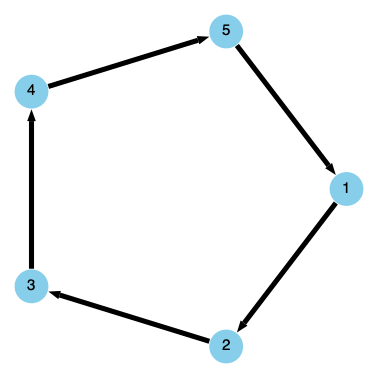

In [2]:
Random.seed!(42)

n = 5

# Cycle
G = DiGraph(n)
for i in 1:(n-1)
    add_edge!(G, i, i+1)
end
add_edge!(G, n, 1)

plot_digraph(G)

In [3]:
"""
Build + solve the Digraph Majority Coloring MILP.

Kwargs:
- strengthen_y::Bool = true  : add y[c] ≤ ∑_v x[v,c] (tightens MILP)
- symmetry_break::Bool = true: add small symmetry breakers
- silent::Bool = true        : silence solver output

Returns:
- model::Model
- x_val::Matrix{Int}  (n×K) assignment matrix (0/1)
- y_val::Vector{Int}  (K) used colors (0/1)
- coloring::Vector{Int} (n) color label 1..4 for each vertex
"""

include("solve_majority_coloring_out.jl")

# --- Example ---
# G = erdos_renyi(SimpleDiGraph, 30, 0.15)
# model, x_val, y_val, coloring = solve_majority_coloring_out(G)
# println("used colors = ", sum(y_val))
# println("coloring = ", coloring)

solve_majority_coloring_out

In [4]:
println("Edges (u -> v):")
for e in edges(G)
    println(src(e), " -> ", dst(e))
end

model, x_val, y_val, coloring = solve_majority_coloring_out(G)

println("\nUsed colors = ", sum(y_val))
println("y = ", y_val)
println("coloring (vertex -> color) = ", coloring)

println("\nAssignment matrix x (rows=v, cols=c):")
display(x_val)

# verify majority constraint
function check_majority_out(G, coloring)
    n = nv(G)
    ok = true
    for v in 1:n
        Nv = outneighbors(G, v)
        dv = length(Nv)
        if dv == 0
            continue
        end
        cv = coloring[v]
        same = count(u -> coloring[u] == cv, Nv)
        if same > fld(dv, 2)
            println("VIOLATION at v=$v: outdeg=$dv, same-color outneighbors=$same > floor(outdeg/2)=$(fld(dv,2))")
            ok = false
        end
    end
    return ok
end

println("\nMajority constraints satisfied? ", check_majority_out(G, coloring))

Edges (u -> v):
1 -> 2
2 -> 3
3 -> 4
4 -> 5
5 -> 1

Used colors = 3
y = [1, 1, 1, 0]
coloring (vertex -> color) = [1, 3, 2, 1, 2]

Assignment matrix x (rows=v, cols=c):


5×4 Matrix{Int64}:
 1  0  0  0
 0  0  1  0
 0  1  0  0
 1  0  0  0
 0  1  0  0


Majority constraints satisfied? true


In [7]:
include("plot_advanced_digraph.jl")

plot_advanced_digraph (generic function with 1 method)

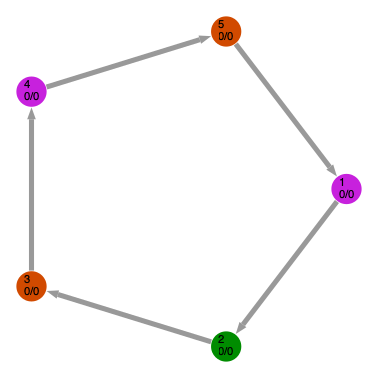

In [8]:
model, x_val, y_val, coloring = solve_majority_coloring_out(G)

plot_advanced_digraph(G, coloring)